# Testing KDE Weighing

This notebook will test the implementation of weighing $\varepsilon$ by its density as

$$\frac{\varepsilon}{\hat{f}(x_i)^{(1/d)}}$$

with $d$ being the maniforld dimension and $\hat{f}(x_i)$ being the KDE evaluated at $x_i$ defined as:

$$\hat{f}(x_i) = \frac{1}{nh^{d}} \sum_{j=1}^{n} K(\frac{x_j-x_i}{h^d})$$

with h being the bandwidth, K being the kernel, and n being number of observations total.

# Goals

1. Implement weighing on a circle with half very dense and half very sparse.
2. Use different kernels and do one with a known pdf
3. try some kde packages

In [ ]:
import numpy as np
# Sample on a circle with half very dense
def sample_circle_half_dense(n, p_dense=0.8, seed=None):
    """
    n points on unit circle.
    p_dense fraction go to dense half: theta in [0, pi)
    rest go to sparse half: theta in [pi, 2pi)
    """
    rng = np.random.default_rng(seed)

    # choose which half each point comes from
    dense_mask = rng.random(n) < p_dense

    theta = np.empty(n)

    # de
    # nse half: [0, pi)
    theta[dense_mask] = rng.uniform(0.0, np.pi, dense_mask.sum())

    # sparse half: [pi, 2pi)
    theta[~dense_mask] = rng.uniform(np.pi, 2*np.pi, (~dense_mask).sum())

    X = np.column_stack([np.cos(theta), np.sin(theta)])
    return X, theta

import matplotlib.pyplot as plt 
def plot_circle_points(X):
    #Plot 2D points sampled on the circle.
    
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], s=10)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Half-Dense Circle")
    plt.show()

In [17]:
import matplotlib.pyplot as plt

def fhat(X, h=0.15, d_manifold=1):

    X = np.asarray(X, dtype=float)
    n, m = X.shape

    # pairwise differences normalized by h: u_ij = (x_j - x_i)/h
    diff = (X[None, :, :] - X[:, None, :]) / h            # (n,n,m)
    r2 = np.sum(diff**2, axis=2)                          # (n,n)

    # Gaussian kernel in R^m
    K = np.exp(-0.5 * r2) / ((2*np.pi) ** (m/2))          # (n,n)

    # KDE at each x_i
    fhat = K.sum(axis=1) / (n * (h ** d_manifold))        # (n,)
    return fhat

def pairwise_dist(X: np.ndarray) -> np.ndarray:
    diff = X[:, None, :] - X[None, :, :]
    return np.linalg.norm(diff, axis = 2)

def weighted_distance_matrix(X, h=0.15, d_manifold=1, sym_rule="min"):
    """
    Build a new distance matrix D_w so that running standard VR with D_w
    equals your density-weighted filtration.
    """
    X = np.asarray(X, dtype=float)

    # base distances (same as your pairwise_dist)
    D = pairwise_dist(X)

    f = fhat(X, h=h, d_manifold=d_manifold)
    f = np.maximum(f, 1e-12)                # safety
    s = f ** (1.0 / d_manifold)             # (n,)

    si = s[:, None]
    sj = s[None, :]

    rule = sym_rule.lower().strip()
    if rule == "min":
        scale = np.maximum(si, sj)
    elif rule == "max":
        scale = np.minimum(si, sj)
    elif rule in {"mean", "avg", "average"}:
        scale = (2.0 * si * sj) / (si + sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, f

def order_vertices_by_eps_neighbors(X: np.ndarray, epsilon: float, D: np.ndarray | None = None):
    X = np.asarray(X, dtype=float)
    if D is None:
        D = pairwise_dist(X)

    deg = (D <= epsilon).sum(axis=1) - 1
    perm = np.argsort(deg, kind="stable")
    inv_perm = np.empty_like(perm)
    inv_perm[perm] = np.arange(len(perm))
    return perm, inv_perm

def Nplus(D: np.ndarray, epsilon: float) -> list[np.ndarray]:
    #precompute Nplus[i] = sorted array of neighbors j > i with D[i,j] <= epsilon
    n = D.shape[0] #number of vertices
    N = []
    for i in range(n):
        js = np.where(D[i, i + 1:] <= epsilon)[0] + (i + 1)
        N.append(js.astype(np.int32))
    return N #prevents double counting and returns the N+ matrix for all vertices

def intersect_two_pointer(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    #Return the intersection of two sorted 1D integer arrays using two pointers.
    a = np.asarray(a, dtype=np.int32)
    b = np.asarray(b, dtype=np.int32)
    if a.size == 0 or b.size == 0:
        return np.empty(0, dtype=np.int32)
    i = 0
    j = 0
    out = []
    while i < a.size and j < b.size: #continue through each set until we hit the end of one
        ai = a[i]
        bj = b[j]

        if ai == bj: #if elements match the belong in the intersection and should be appended
            out.append(ai)
            i += 1 #move both pointers forward
            j += 1
        elif ai < bj:
            i += 1 #since arrays are sorted any ai < bj will neber match it or anything after it so advance pointer i
        else: #if b[j] is smaller it cant match anything in a at this position so move pointer j
            j += 1
    return np.array(out, dtype=np.int32)
    # this is how we enforce that future vertices must neighbor all current simplex vertices

def order_vertices_by_eps_neighbors(X: np.ndarray, epsilon: float) -> tuple[np.ndarray, np.ndarray]:
    #perm: length-n array of OLD indices in NEW order (increasing eps-neighbor count)
    #inv_perm: length-n array mapping OLD index -> NEW index
    
    X = np.asarray(X, dtype=float)
    D = pairwise_dist(X)

    # degree in the FULL epsilon-graph (exclude self)
    deg = (D <= epsilon).sum(axis=1) - 1

    # stable sort so ties keep original order
    perm = np.argsort(deg, kind="stable")
    inv_perm = np.empty_like(perm)
    inv_perm[perm] = np.arange(len(perm))
    return perm, inv_perm

def local_contributions_vr(X: np.ndarray, epsilon: float, max_dim: int | None = None, D: np.ndarray | None = None):
    X = np.asarray(X, dtype=float)
    n = X.shape[0]

    if D is None:
        D = pairwise_dist(X)

    N = Nplus(D, epsilon)

    # reorder vertices by increasing number of epsilon-neighbors
    deg = (D <= epsilon).sum(axis=1) - 1
    perm = np.argsort(deg, kind="stable")
    if not np.all(perm == np.arange(n)):
        X = X[perm]
        D = D[np.ix_(perm, perm)]
        N = Nplus(D, epsilon)

    C: list[tuple[float, int]] = []

    def expand(simplex: list[int], candidates: np.ndarray, f_simplex: float):
        dim = len(simplex) - 1
        sign = 1 if (dim % 2 == 0) else -1
        C.append((f_simplex, sign))

        if max_dim is not None and dim >= max_dim:
            return

        for v in candidates:
            v = int(v)
            longest_edge = 0.0
            for u in simplex:
                d_uv = D[u, v]
                if d_uv > longest_edge:
                    longest_edge = d_uv
            f_new = max(f_simplex, longest_edge)

            candidates_new = intersect_two_pointer(candidates, N[v])
            simplex.append(v)
            expand(simplex, candidates_new, f_new)
            simplex.pop()

    for i in range(n):
        expand([i], N[i], 0.0)

    C.sort(key=lambda t: t[0])
    return C

#computes the EC from C
def EC_from_C(C: list[tuple[float, int]]):
    # Edge case: no events
    if not C:
        return lambda r: 0

    # Split C into two arrays: filtration values and signs
    filtration_values = np.array([f for (f, _) in C], dtype=float)
    signs = np.array([s for (_, s) in C], dtype=int)

    # Prefix sums: prefix_sums[k] = sum of signs from 0 through k
    prefix_sums = np.cumsum(signs)

    def chi(r: float) -> int:
        """
        Euler characteristic at radius r:
        include all events with filtration_value <= r.
        """
        # number of events with f <= r
        k = np.searchsorted(filtration_values, r, side="right")

        # sum of first k signs
        if k == 0:
            return 0
        return int(prefix_sums[k - 1])

    return chi

def ECC_from_C(
    C: list[tuple[float, int]],
    r_min: float,
    r_max: float,
    num: int = 200,
) -> tuple[np.ndarray, np.ndarray]:
    #Compute the Euler Characteristic Curve (ECC) from an event list C.

    # Edge case: no events
    if not C:
        r_grid = np.linspace(r_min, r_max, num=num)
        return r_grid, np.zeros_like(r_grid, dtype=int)

    # Assumes C is sorted by filtration value (local_contributions_vr already sorts)
    filtration_values = np.array([f for (f, _) in C], dtype=float)
    signs = np.array([s for (_, s) in C], dtype=int)
    prefix_sums = np.cumsum(signs)

    r_grid = np.linspace(r_min, r_max, num=num)

    # For each r, include all events with filtration_value <= r
    k = np.searchsorted(filtration_values, r_grid, side="right")
    ecc = np.zeros_like(k, dtype=int)

    mask = k > 0
    ecc[mask] = prefix_sums[k[mask] - 1]

    return r_grid, ecc

def plot_ECC_from_C(
    C: list[tuple[float, int]],
    eps_min: float,
    eps_max: float,
    num: int = 200,
    title: str = "Euler Characteristic Curve (ECC)",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Convenience function: compute ECC on [eps_min, eps_max] and plot it.
    Returns (r_grid, ecc).
    """
    r_grid, ecc = ECC_from_C(C, eps_min, eps_max, num=num)

    plt.figure()
    # ECC is a right-continuous step function of epsilon
    plt.step(r_grid, ecc, where="post")
    plt.xlim(eps_min, eps_max)
    plt.xlabel("epsilon (r)")
    plt.ylabel("chi(r)")
    plt.title(title)
    plt.show()

    return r_grid, ecc



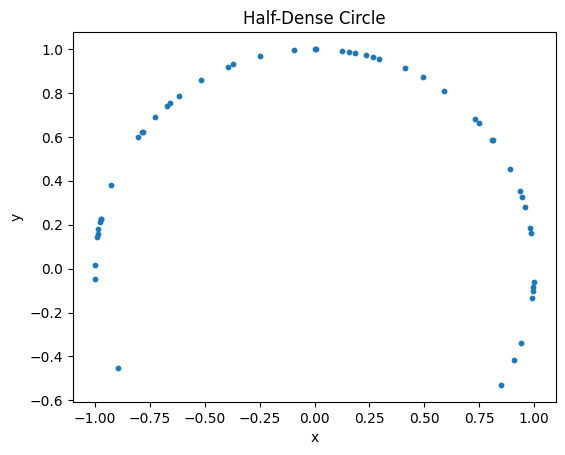

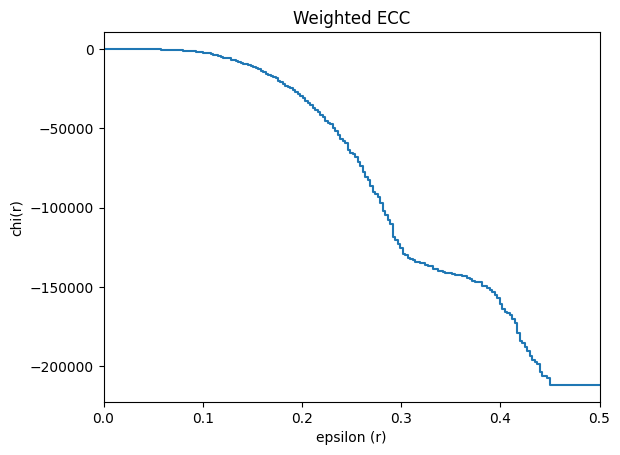

(array([0.        , 0.00251256, 0.00502513, 0.00753769, 0.01005025,
        0.01256281, 0.01507538, 0.01758794, 0.0201005 , 0.02261307,
        0.02512563, 0.02763819, 0.03015075, 0.03266332, 0.03517588,
        0.03768844, 0.04020101, 0.04271357, 0.04522613, 0.04773869,
        0.05025126, 0.05276382, 0.05527638, 0.05778894, 0.06030151,
        0.06281407, 0.06532663, 0.0678392 , 0.07035176, 0.07286432,
        0.07537688, 0.07788945, 0.08040201, 0.08291457, 0.08542714,
        0.0879397 , 0.09045226, 0.09296482, 0.09547739, 0.09798995,
        0.10050251, 0.10301508, 0.10552764, 0.1080402 , 0.11055276,
        0.11306533, 0.11557789, 0.11809045, 0.12060302, 0.12311558,
        0.12562814, 0.1281407 , 0.13065327, 0.13316583, 0.13567839,
        0.13819095, 0.14070352, 0.14321608, 0.14572864, 0.14824121,
        0.15075377, 0.15326633, 0.15577889, 0.15829146, 0.16080402,
        0.16331658, 0.16582915, 0.16834171, 0.17085427, 0.17336683,
        0.1758794 , 0.17839196, 0.18090452, 0.18

In [32]:
X, theta = sample_circle_half_dense(
    n=50,        
    p_dense=0.85,   # x% in top half
    seed=0 
)
plot_circle_points(X)
D_w, _ = weighted_distance_matrix(X, h=0.08, d_manifold=1, sym_rule="min")
Cw = local_contributions_vr(X, epsilon=0.5, max_dim=3, D=D_w)
plot_ECC_from_C(Cw, eps_min=0.0, eps_max=0.5, num=200, title="Weighted ECC")



In [36]:
def edge_stats(D, eps):
    A = (D <= eps)
    np.fill_diagonal(A, False)
    deg = A.sum(axis=1)
    m_edges = deg.sum() // 2
    return deg.mean(), m_edges

eps = 0.3

degD, edgesD = edge_stats(D, eps)
degW, edgesW = edge_stats(D_w, eps)
print("avg degree D:", degD, "edges D:", edgesD)
print("avg degree W:", degW, "edges W:", edgesW)

def triangle_count(D, eps):
    A = (D <= eps).astype(int)
    np.fill_diagonal(A, 0)
    A3 = A @ A @ A
    return int(np.trace(A3) // 6)

print("triangles D:", triangle_count(D, eps))
print("triangles W:", triangle_count(D_w, eps))

avg degree D: 26.94 edges D: 2694
avg degree W: 43.04 edges W: 1076
triangles D: 19890
triangles W: 14426
